Original Columns:
 Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

Cleaned Columns:
 Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales'],
      dtype='str')

⚠️ Profit column not found — skipping profit KPIs

===== KPIs =====
Total Revenue: 2261536.78
Total Orders: 4922
Average Order Value: 459.48


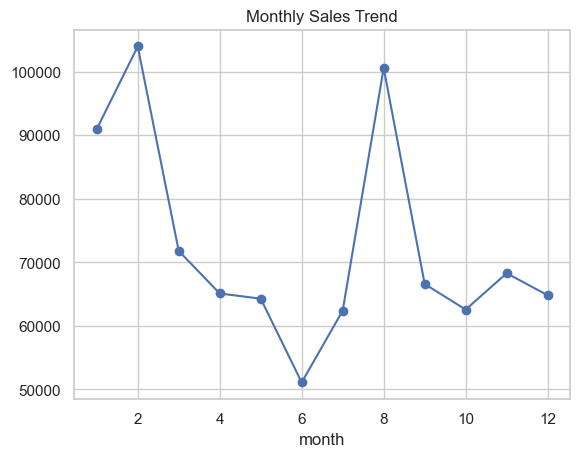

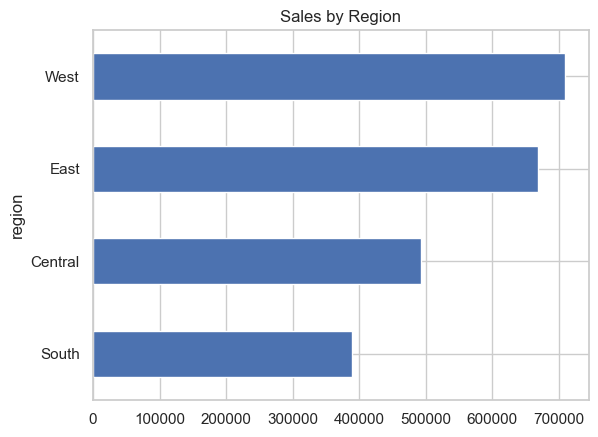

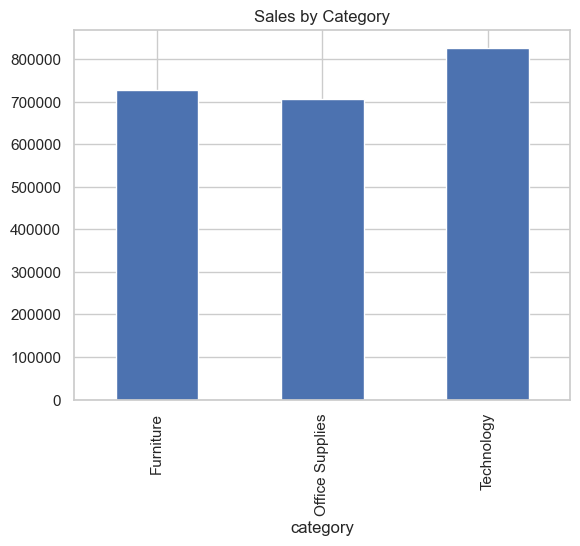

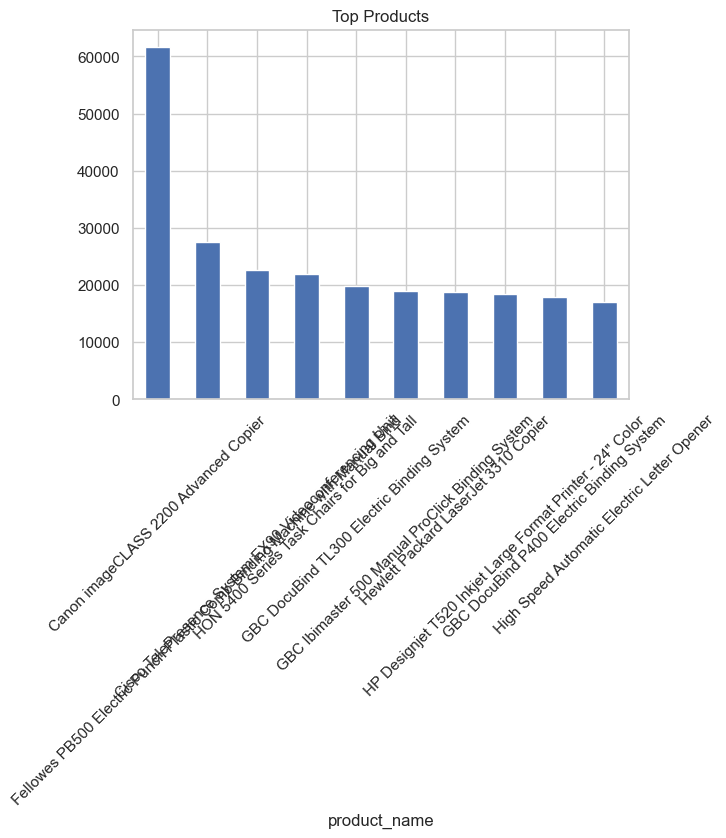

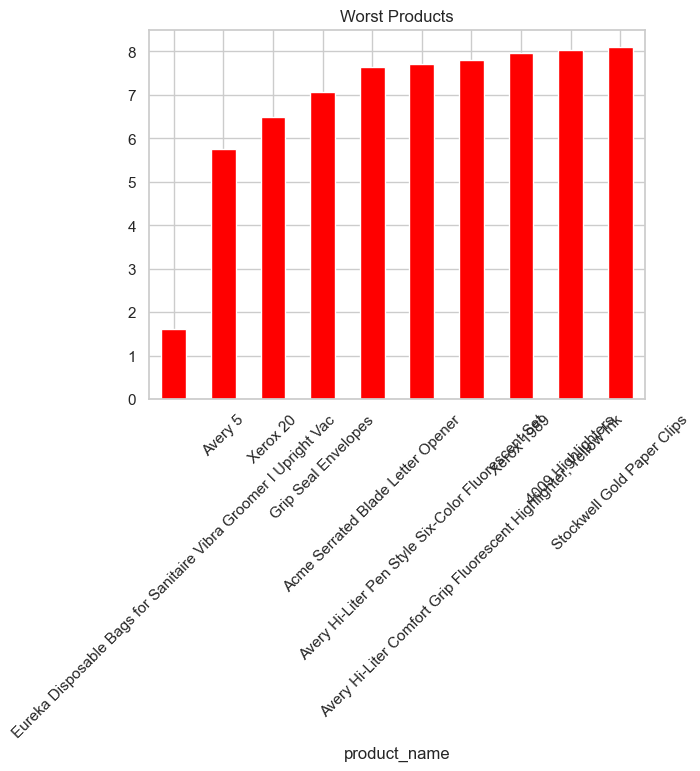

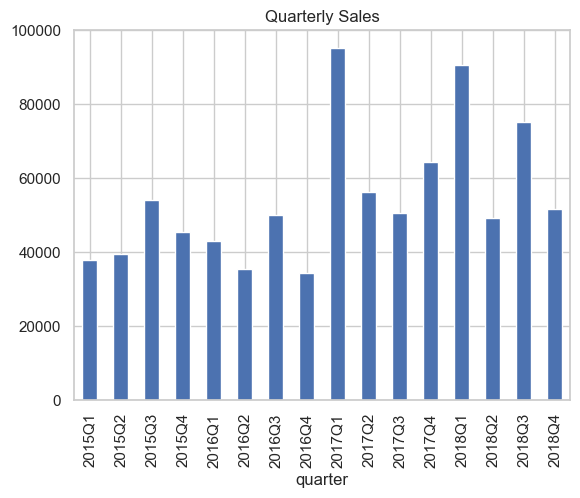


✅ DONE — Your analysis ran successfully!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# LOAD DATA
file_path = "train.csv"
df = pd.read_csv(file_path)

print("Original Columns:\n", df.columns)

# CLEAN COLUMN NAMES 
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\nCleaned Columns:\n", df.columns)

# AUTO COLUMN DETECTION 
def find_col(possible):
    for col in possible:
        if col in df.columns:
            return col
    return None

sales_col = find_col(["sales", "revenue"])
profit_col = find_col(["profit"])
order_col = find_col(["order_id", "orderid", "id"])
date_col = find_col(["order_date", "date"])
region_col = find_col(["region"])
category_col = find_col(["category"])
subcat_col = find_col(["sub_category", "subcategory"])
product_col = find_col(["product_name", "product"])

# CHECK REQUIRED 
if sales_col is None or date_col is None:
    print("\n❌ ERROR: Required columns not found.")
    print("Available columns:", df.columns)
    exit()

#  DATA CLEANING 
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[sales_col])
df = df.drop_duplicates()

# If profit not available, create dummy (optional)
if profit_col is None:
    print("\n⚠️ Profit column not found — skipping profit KPIs")

# FEATURE ENGINEERING 
df['year'] = df[date_col].dt.year
df['month'] = df[date_col].dt.month
df['quarter'] = df[date_col].dt.to_period('Q')

# KPIs 
total_revenue = df[sales_col].sum()
total_orders = df[order_col].nunique() if order_col else len(df)
aov = total_revenue / total_orders

print("\n===== KPIs =====")
print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(aov, 2))

if profit_col:
    total_profit = df[profit_col].sum()
    profit_margin = total_profit / total_revenue
    print("Total Profit:", round(total_profit, 2))
    print("Profit Margin:", round(profit_margin * 100, 2), "%")

# VISUALIZATIONS 

# Monthly Sales Trend
df.groupby('month')[sales_col].sum().plot(marker='o', title="Monthly Sales Trend")
plt.show()

# Region Analysis
if region_col:
    df.groupby(region_col)[sales_col].sum().sort_values().plot(kind='barh', title="Sales by Region")
    plt.show()

# Category Analysis
if category_col:
    df.groupby(category_col)[sales_col].sum().plot(kind='bar', title="Sales by Category")
    plt.show()

# Sub-category
if subcat_col:
    df.groupby(subcat_col)[sales_col].sum().sort_values().plot(kind='barh', title="Sub-category Sales")
    plt.show()

# Top Products
if product_col:
    df.groupby(product_col)[sales_col].sum().sort_values(ascending=False).head(10).plot(kind='bar', title="Top Products")
    plt.xticks(rotation=45)
    plt.show()

# Worst Products
if product_col:
    df.groupby(product_col)[sales_col].sum().sort_values().head(10).plot(kind='bar', color='red', title="Worst Products")
    plt.xticks(rotation=45)
    plt.show()

# Seasonality (Quarter)
df.groupby('quarter')[sales_col].sum().plot(kind='bar', title="Quarterly Sales")
plt.show()

print("\n✅ DONE — Your analysis ran successfully!")